# Introduction

This notebook contains the code for the simulation environment used in the project. It defines the classes and functions needed to simulate the operation of a battery storage system in an electricity market, including the state representation, action space, exogenous data generation, and simulation loop. 

The environment is designed to be flexible and extensible, allowing for different policies and exogenous data generators to be easily integrated.



## Importing libraries

The following libraries are imported for use in the simulation environment:

In [2]:
import numpy as np
import pandas as pd
from pyomo.environ import *
from copy import deepcopy
import matplotlib.pyplot as plt
import pickle
import torch

# Simulation Environment

We are going to create a simulation environment to model the energy market for a single consumer. 
The consumer is small enough to not affect the market price, as this would otherwise make the problem more complex. 
It takes the market price $p_t$ as given.

We also assume that the consumer knows their own energy consumption patterns in advance and it is $d_t$ for each time period $t$. 
For many consumers, this is a reasonable assumption, as much of energy consumption is predictable (e.g., heating, cooling, appliances). 
Some consumers may have more variable consumption patterns, but this would require a more complex model to capture the uncertainty in demand.

We assume that the demand must be met at all times, meaning that the consumer cannot simply choose to not consume energy during peak hours.
This is a reasonable assumption, as most consumers have essential energy needs that cannot be easily shifted (e.g., heating, cooling, lighting), and if they could be shifted, you could simply shift them to off-peak hours.

The consumer buys $e_t$ kWh of energy from the market at time $t$.

The consumer has a battery of size X kWh.
The battery has a maximum charge and discharge rate of Y kW per hour.
The battery has an efficiency of Z%, meaning that if you charge the battery with 1 kWh, you can only get Z kWh out of it.

The price of the battery should be investigated, as it may not be cost-effective for all consumers to invest in a battery.


Degradation of the battery should also be taken into account, as it may affect the long-term cost-effectiveness of the battery.
Lifetime of the battery should also be considered, as it may affect the long-term cost-effectiveness of the battery.


## Environment




## State
Battery level, $b_t$
Market prices, $p_t$
If some demand is unpredictable, we could also include this $d^{\text{unpredictable}}_t$, in the state.
Other factors that could be included in the state to help the agent predict future market prices like weather conditions or economic indicators.

## Action
Each hour decide how much energy to buy, $e_t$.
If bigger than demand, the excess energy is stored in the battery.
If smaller than demand, the deficit is covered by the battery.


## Dynamics
If $e_t > d_t$, then the excess energy is stored in the battery, and the battery level increases by $(e_t - d_t) * Z\%$.
$$b_{t+1} = b_t + (e_t - d_t) * Z\% $$
If $e_t < d_t$, then the deficit is covered by the battery, and the battery level decreases by $d_t - e_t$.
$$b_{t+1} = b_t - (d_t - e_t)$$

The other factors market prices, unpredictable demand, weather conditions, and economic indicators are exogenous and can be modeled as stochastic processes or based on historical data. 

## Feasibility
$0 \leq b_t \leq X$ (battery capacity constraint)
$abs(e_t - d_t) \leq Y$ (charge/discharge rate constraint)



## Reward (cost)
p_t * e_t

## Episode
each day the new markets prices are revealed
each hour new others factors are revealed (e.g., weather conditions, economic indicators)

In [3]:
class State:
    def __init__(self, time_step, battery_level, energy_price, carbon_intensity, other_factors=None):
        self.time_step = time_step
        self.battery_level = battery_level
        self.energy_price = energy_price
        self.carbon_intensity = carbon_intensity
        self.other_factors = other_factors



In [4]:

class Action:
    def __init__(self, buy_energy_amount):
        self.buy_energy_amount = buy_energy_amount


In [5]:
class Cost: 
    def __init__(self, amount, carbon_emissions, green_factor):
        self.amount = amount
        self.carbon_emissions = carbon_emissions
        self.weighted_cost = (1 - green_factor) * amount + green_factor * carbon_emissions



In [6]:
class Parameters:
    def __init__(self, initial_battery_level, max_battery_capacity, max_charging_rate, max_discharging_rate, charge_efficiency, discharge_efficiency, green_factor):
        self.initial_battery_level = initial_battery_level
        self.max_battery_capacity = max_battery_capacity
        self.max_charging_rate = max_charging_rate
        self.max_discharging_rate = max_discharging_rate
        self.charge_efficiency = charge_efficiency
        self.discharge_efficiency = discharge_efficiency
        self.green_factor = green_factor


class ExogenousValues:
    def __init__(self, energy_price, carbon_intensity, other_factors=None):
        self.energy_price = energy_price
        self.carbon_intensity = carbon_intensity
        self.other_factors = other_factors

class ExogenousTrajectory:
    def __init__(self, zone, exogen_values_list, demand_list):
        self.zone = zone
        self.exogen_values_list = exogen_values_list
        self.demand_list = demand_list



In [7]:
class SimulationResult:
    def __init__(self, exogen_trajectory=None):
        self.exogen_trajectory = exogen_trajectory
        self.states = []
        self.actions = []
        self.costs = []


    def get_total_cost(self, cost_type):
        return sum(getattr(cost, cost_type) for cost in self.costs)
    
    def is_similar_to(self, other_simulation_result, tolerance=1e-6):
        for t in range(len(self.states)):
            assert abs(self.states[t].energy_price - self.exogen_trajectory.exogen_values_list[t].energy_price) <= tolerance, f"States differ at time step {t}: {self.states[t].energy_price} vs {self.exogen_trajectory.exogen_values_list[t].energy_price}"
            assert abs(self.states[t].carbon_intensity - self.exogen_trajectory.exogen_values_list[t].carbon_intensity) <= tolerance, f"States differ at time step {t}: {self.states[t].carbon_intensity} vs {self.exogen_trajectory.exogen_values_list[t].carbon_intensity}"

        for t in range(len(self.states)):
            assert abs(self.states[t].battery_level - other_simulation_result.states[t].battery_level) <= tolerance, f"States differ at time step {t}: {self.states[t].battery_level} vs {other_simulation_result.states[t].battery_level}"
            assert abs(self.states[t].energy_price - other_simulation_result.states[t].energy_price) <= tolerance, f"States differ at time step {t}: {self.states[t].energy_price} vs {other_simulation_result.states[t].energy_price}"
            #assert abs(self.states[t].carbon_intensity - other_simulation_result.states[t].carbon_intensity) <= tolerance, f"States differ at time step {t}: {self.states[t].carbon_intensity} vs {other_simulation_result.states[t].carbon_intensity}"

        for t in range(len(self.actions)):
            assert abs(self.actions[t].buy_energy_amount - other_simulation_result.actions[t].buy_energy_amount) <= tolerance, f"Actions differ at time step {t}: {self.actions[t].buy_energy_amount} vs {other_simulation_result.actions[t].buy_energy_amount}"

        for t in range(len(self.costs)):
            assert abs(self.costs[t].amount - other_simulation_result.costs[t].amount) <= tolerance, f"Costs differ at time step {t}: {self.costs[t].amount} vs {other_simulation_result.costs[t].amount}"
            #assert abs(self.costs[t].carbon_emissions - other_simulation_result.costs[t].carbon_emissions) <= tolerance, f"Costs differ at time step {t}: {self.costs[t].carbon_emissions} vs {other_simulation_result.costs[t].carbon_emissions}"
            assert abs(self.costs[t].weighted_cost - other_simulation_result.costs[t].weighted_cost) <= tolerance, f"Costs differ at time step {t}: {self.costs[t].weighted_cost} vs {other_simulation_result.costs[t].weighted_cost}"
            
    def plot(self, environment, start=0, end=None):
        # price
        plt.figure(figsize=(14, 16))
        plt.title(f"Simulation Result for Exogenous Trajectory: {self.exogen_trajectory.zone} (start={start}, end={end})")
        plt.subplot(6, 1, 1)
        plt.plot(range(start, end), [state.energy_price for state in self.states[start:end]], label='Energy Price (EUR/kWh)')
        plt.ylabel('Energy Price (EUR/kWh)')
        plt.legend()
        # carbon intensity
        plt.subplot(6, 1, 2)
        plt.plot(range(start, end), [state.carbon_intensity for state in self.states[start:end]], label='Carbon Intensity (kgCO2/kWh)', color='orange')
        plt.ylabel('Carbon Intensity (kgCO2/kWh)')
        plt.legend()
        # demand 
        plt.subplot(6, 1, 3)
        plt.plot(range(start, end), [environment.demand_profile[state.time_step] for state in self.states[start:end]], label='Demand (kWh)', color='blue')
        plt.ylabel('Demand (kWh)')
        plt.legend()
        # buy energy amount
        plt.subplot(6, 1, 4)
        plt.plot(range(start, end), [action.buy_energy_amount for action in self.actions[start:end]], label='Energy Bought (kWh)', color='red')
        plt.ylabel('Energy Bought (kWh)')
        plt.xlabel('Time Step')
        plt.legend()
        # excess energy (positive for charging, negative for discharging)
        plt.subplot(6, 1, 5)
        plt.plot(range(start, end), [action.buy_energy_amount - environment.demand_profile[state.time_step] for state, action in zip(self.states[start:end], self.actions[start:end])], label='Excess Energy (kWh)', color='purple')
        plt.ylabel('Excess Energy (kWh)')
        plt.xlabel('Time Step')
        plt.legend()
        # battery level
        plt.subplot(6, 1, 6)
        plt.plot(range(start, end), [state.battery_level for state in self.states[start:end]], label='Battery Level (kWh)', color='green')
        plt.ylabel('Battery Level (kWh)')
        plt.xlabel('Time Step')
        plt.legend()
        plt.show()

class EvaluationResult:
    def __init__(self, policy_name):
        self.policy_name = policy_name
        self.simulation_results = []

    def print_average_costs(self):
        for cost_type in ['amount', 'carbon_emissions', 'weighted_cost']:
            avg_cost = sum(sim.get_total_cost(cost_type) for sim in self.simulation_results) / len(self.simulation_results)
            print(f"Average {cost_type}: {avg_cost:.2f}")
        


In [8]:
class Environment:
    def __init__(self, parameters, epsilon=1e-4):
        self.parameters = parameters
        self.epsilon = epsilon
        self.demand_profile = None  # This will be set for each simulation based on the exogenous trajectory being used


    def check_and_fix_action(self, state, action):
        # return True if action is feasible in the given state, else False

        if action.buy_energy_amount > self.demand_profile[state.time_step]:  # Charging
            lowest_max_limit = min(self.demand_profile[state.time_step] + self.parameters.max_charging_rate,
                               self.demand_profile[state.time_step] + (self.parameters.max_battery_capacity - state.battery_level) / self.parameters.charge_efficiency)
            
            if action.buy_energy_amount > lowest_max_limit + self.epsilon:
                print("Action exceeds limits for charging.")
                print(f"Action buy energy amount: {action.buy_energy_amount} kWh")
                print(f"Demand at time step {state.time_step}: {self.demand_profile[state.time_step]} kWh")
                print(f"Lowest limit for charging: {lowest_max_limit} kWh")
                print(f"Battery level: {state.battery_level} kWh")
                
                raise ValueError("Action exceeds limits for charging.")
            elif action.buy_energy_amount > lowest_max_limit:
                action.buy_energy_amount = lowest_max_limit

        else:  # Discharging
            highest_min_limit = max(self.demand_profile[state.time_step] - self.parameters.max_discharging_rate * self.parameters.discharge_efficiency,
                                    self.demand_profile[state.time_step] - state.battery_level * self.parameters.discharge_efficiency)


            if  action.buy_energy_amount < highest_min_limit - self.epsilon:
                print("Action exceeds limits for discharging.")
                print(f"Action buy energy amount: {action.buy_energy_amount} kWh")
                print(f"Demand at time step {state.time_step}: {self.demand_profile[state.time_step]} kWh")
                print(f"Highest limit for discharging: {highest_min_limit} kWh")
                print(f"Battery level: {state.battery_level} kWh")
                
                raise ValueError("Action exceeds limits for discharging.")
            elif action.buy_energy_amount < highest_min_limit:
                action.buy_energy_amount = highest_min_limit

        return action

    def get_cost(self, state, action):
        # return cost of taking action in the given state
        energy_cost_amount = action.buy_energy_amount * state.energy_price
        carbon_emissions = action.buy_energy_amount * state.carbon_intensity
        return Cost(amount=energy_cost_amount, carbon_emissions=carbon_emissions, green_factor=self.parameters.green_factor)

    def transition(self, state, action, next_exogen_values):
        # return next state
        excess_energy = action.buy_energy_amount - self.demand_profile[state.time_step]

        # update battery level based on action
        if excess_energy > 0:  # Charging
            new_battery_level = state.battery_level + excess_energy * self.parameters.charge_efficiency
        else:  # Discharging
            new_battery_level = state.battery_level + excess_energy / self.parameters.discharge_efficiency  # excess_energy is negative for discharging

        # get next exogen values
        return State(time_step=state.time_step + 1,
                     battery_level=new_battery_level,
                     energy_price=next_exogen_values.energy_price,
                     carbon_intensity=next_exogen_values.carbon_intensity,
                     other_factors=next_exogen_values.other_factors)
    
    def do_simulation(self, policy, exogen_trajectory):
        self.demand_profile = exogen_trajectory.demand_list
        exogen_data = exogen_trajectory.exogen_values_list

        if policy.is_hindsight_policy:
            policy.see_future_exogen_values(exogen_data)

        result = SimulationResult(exogen_trajectory)

        state = State(time_step=0,
                        battery_level=self.parameters.initial_battery_level,
                        energy_price=exogen_data[0].energy_price,
                        carbon_intensity=exogen_data[0].carbon_intensity,
                        other_factors=exogen_data[0].other_factors)

        for t in range(len(exogen_data)):
            result.states.append(state)

            policy_action = policy.select_action(state)
            policy_action = self.check_and_fix_action(state, policy_action)
            
            result.actions.append(policy_action)
            
            
            cost = self.get_cost(state, policy_action)
            result.costs.append(cost)

            if t < len(exogen_data) - 1:  # No need to transition on the last step
                next_exogen_values = exogen_data[t + 1]
                state = self.transition(state, policy_action, next_exogen_values)

        if policy.expected_simulation_result is not None:
            # check that hindsight policy actions are the same as optimal actions
            result.is_similar_to(policy.expected_simulation_result, tolerance=self.epsilon)

        return result
        

    def evaluate_policies(self, policies, all_exogen_trajectories):

        all_results = []
        for policy in policies:
            policy_name = policy.__name__
            print(f"Evaluating policy: {policy_name}")
            result = EvaluationResult(policy_name)
        
            for sim, exogen_trajectory in enumerate(all_exogen_trajectories):
                print(f"  Simulation {sim + 1}/{len(all_exogen_trajectories)} ({exogen_trajectory.zone})")
                
                policy_instance = policy(self)
                simulation_result = self.do_simulation(policy_instance, exogen_trajectory)
                result.simulation_results.append(simulation_result)

                
            print(f"Policy {policy_name} evaluation completed.")
            result.print_average_costs()
            
            all_results.append(result)

        return all_results


    

In [ ]:
import LSTM_PRICE

with open("lstm_model.pickle", "rb") as f:
    lstmData = pickle.load(f)

trainedLstmScaler = lstmData.get("scaler")
trainedLstmFeatures = lstmData.get("features", [])
trainedLstmSeqLen = lstmData.get("SEQ_LEN", 48)
trainedLstmHorizon = lstmData.get("HORIZON", 72)

Tensor should be in shape TARGETSxSEQUENCExFEATURES

The target is price so TARGETS = 1. The sequence length can be found in SEQ_LEN, SEQUENCE=SEQ_LEN. FEATURES = features.shape.

There is some data that has to be added the following sections shows what needs to be done.

In [ ]:
data["lag_1"] = data["value_spot"].shift(1)
data["lag_2"] = data["value_spot"].shift(2)
data["lag_24"] = data["value_spot"].shift(24)
data["lag_168"] = data["value_spot"].shift(24*7)

data = data.ffill()




# IMPORT
data["import"] = data["import"].apply(ast.literal_eval)
import_expanded = data["import"].apply(pd.Series).add_prefix("import_")

# EXPORT
data["export"] = data["export"].apply(ast.literal_eval)
export_expanded = data["export"].apply(pd.Series).add_prefix("export_")

# Combine everything
data = pd.concat(
    [data.drop(columns=["import", "export"]), import_expanded, export_expanded],
    axis=1
)



data["mix"] = data["mix"].apply(ast.literal_eval)
expanded = data["mix"].apply(pd.Series)
data = pd.concat([data.drop(columns=["mix"]), expanded], axis=1)



data = data.join(data["flows"].apply(pd.Series))

data = data.fillna(0)

data = data.drop(columns=["emissionFactorType", "battery storage", "hydro storage", "flows", "unit_spot", "unit_total_load"])

data["rolling_mean_24"] = data["value_spot"].rolling(window=24).mean()


data["hour_sin"] = np.sin(2 * np.pi * data["hour"] / 24)
data["hour_cos"] = np.cos(2 * np.pi * data["hour"] / 24)

data["weekday_sin"] = np.sin(2 * np.pi * data["day_of_week"] / 7)
data["weekday_cos"] = np.cos(2 * np.pi * data["day_of_week"] / 7)

data["month_sin"] = np.sin(2 * np.pi * (data["month"] -1) / 12)
data["month_cos"] = np.cos(2 * np.pi * (data["month"] -1)/ 12)

The data has to go through create_sequence to be the right size

In [ ]:
X = data.drop(columns=["value_spot"]).values
hours = data["hour"].values
xInput = LSTM_PRICE.create_sequences(X, hours, seq_len=trainedLstmSeqLen, HORIZON=trainedLstmHorizon)


First, you have to read the pickle file.
The pickle file includes, the weights and biases of the model, the scaler, input dimension and horizon

Features that should be included are located in data["Features"].
Some of the features are preprocessed.


In [ ]:


trainedLstmModel = LSTM_PRICE.LSTMModelPrice(input_dim=lstmData["input_dim"], HORIZON=lstmData["HORIZON"])
trainedLstmModel.load_state_dict(lstmData["model_state"])
trainedLstmModel.eval()



exampleInput = torch.tensor(lstmData["example_input"], dtype=torch.float32)
with torch.no_grad():
    examplePrediction = trainedLstmModel(exampleInput)
    prediction = trainedLstmModel(torch.tensor(xInput, dtype=torch.float32))

print(exampleInput.shape)
print(lstmData.keys())
print("Example prediction shape:", examplePrediction.shape)

print(examplePrediction)

dict_keys(['model_state', 'scaler', 'input_dim', 'features', 'HORIZON', 'SEQ_LEN', 'example_input'])
Example prediction shape: torch.Size([1, 72])


## Agent
Represents a consumer who wants to minimize their energy costs by deciding how much energy to buy from the market.

Its primary method is select_action(state), which takes the current state as input and returns the action (amount of energy to buy) that the agent decides to take.

In [10]:
class Agent:
    def __init__(self, environment):
        self.environment = environment
        self.is_hindsight_policy = False  # Set to True for hindsight agents that can see future exogenous values
        self.expected_simulation_result = None  # For hindsight agents to store the expected optimal simulation result based on the exogenous data they see

    def see_future_exogen_values(self, exogen_data):
        raise NotImplementedError("This method should be implemented by hindsight agents that can see future exogenous values")

    def select_action(self, state):
        # return action based on the current state
        raise NotImplementedError("This method should be implemented by subclasses")

### The dummy agent
The dummy agent is a simple baseline that always buys exactly the amount of energy needed to meet the demand, without using the battery at all.

In [11]:
class DummyAgent(Agent):
    def select_action(self, state):
        return Action(buy_energy_amount=self.environment.demand_profile[state.time_step])
    

### The optimal in hindsight agent

In [12]:
def solve_MILP_model(exogen_data, parameters, demand_profile, value_of_battery_at_end_of_day=0):
    model = ConcreteModel()
    # Sets
    time_steps = range(len(exogen_data))
    model.T = Set(initialize=time_steps)

    # Parameters
    model.demand = Param(model.T, initialize={t: demand_profile[t] for t in model.T})
    model.energy_price = Param(model.T, initialize={t: exogen_data[t].energy_price for t in model.T})
    model.carbon_intensity = Param(model.T, initialize={t: exogen_data[t].carbon_intensity for t in model.T})

    model.max_battery_capacity = Param(initialize=parameters.max_battery_capacity)
    model.max_charging_rate = Param(initialize=parameters.max_charging_rate)
    model.max_discharging_rate = Param(initialize=parameters.max_discharging_rate)
    model.charge_efficiency = Param(initialize=parameters.charge_efficiency)
    model.discharge_efficiency = Param(initialize=parameters.discharge_efficiency)
    model.green_factor = Param(initialize=parameters.green_factor)

    model.value_of_battery_at_end_of_day = Param(initialize=value_of_battery_at_end_of_day)


    # Variables
    model.buy_energy = Var(model.T, within=NonNegativeReals)
    model.charge_battery = Var(model.T, within=NonNegativeReals)
    model.discharge_battery = Var(model.T, within=NonNegativeReals)
    model.battery_level = Var(model.T, within=NonNegativeReals)
    model.charge = Var(model.T, within=Binary)  # 1 if charging, 0 if discharging

    # Objective
    def objective_rule(m):
        last_time_step = max(m.T)
        last_battery_level = m.battery_level[last_time_step] + m.charge_battery[last_time_step] * m.charge_efficiency - m.discharge_battery[last_time_step]
        return sum(
            (1 - m.green_factor) * m.buy_energy[t] * m.energy_price[t] + 
            m.green_factor * m.buy_energy[t] * m.carbon_intensity[t]
            for t in m.T
        ) - m.value_of_battery_at_end_of_day * last_battery_level
    model.objective = Objective(rule=objective_rule, sense=minimize)

    # Constraints
    # Demand must be met at each time step
    def demand_constraint_rule(m, t):
        return m.buy_energy[t] + m.discharge_battery[t] * m.discharge_efficiency == m.demand[t] + m.charge_battery[t]
    
    model.demand_constraint = Constraint(model.T, rule=demand_constraint_rule)

    # Battery level constraints
    def battery_level_rule(m, t):
        return m.battery_level[t] <= m.max_battery_capacity

    model.battery_capacity_constraint = Constraint(model.T, rule=battery_level_rule)

    def final_battery_level_rule(m):
        last_time_step = max(m.T)
        return m.battery_level[last_time_step] + m.charge_battery[last_time_step] * m.charge_efficiency - m.discharge_battery[last_time_step] <= m.max_battery_capacity
    
    model.final_battery_level_constraint = Constraint(rule=final_battery_level_rule)

    # Max charging and discharging rates
    def charging_rate_rule(m, t):
        return m.charge_battery[t] <= m.max_charging_rate * m.charge[t]
    model.charging_rate_constraint = Constraint(model.T, rule=charging_rate_rule)

    def discharging_rate_rule(m, t):
        return m.discharge_battery[t] <= m.max_discharging_rate * (1 - m.charge[t])
    model.discharging_rate_constraint = Constraint(model.T, rule=discharging_rate_rule)

    def discharging_less_than_battery_rule(m, t):
        return m.discharge_battery[t] <= m.battery_level[t]
    
    model.discharging_battery_constraint = Constraint(model.T, rule=discharging_less_than_battery_rule)

    # Battery level dynamics
    def battery_dynamics_rule(m, t):
        if t == 0:
            return m.battery_level[t] == parameters.initial_battery_level
        else:
            return m.battery_level[t] == m.battery_level[t-1] + m.charge_battery[t-1] * m.charge_efficiency - m.discharge_battery[t-1]
    model.battery_dynamics_constraint = Constraint(model.T, rule=battery_dynamics_rule)
    
    # Solve the model
    solver = SolverFactory('gurobi')
    if not solver.available():
        raise RuntimeError("Gurobi solver is not available in your environment.")
    results = solver.solve(model, tee=False)
    status = results.Solver()['Termination condition'].value
    assert status == 'optimal', f'error occurred, status: {status}.  Check model!'
    return model
    

In [13]:
class OptimalHindsightAgent(Agent):
    def __init__(self, environment):
        super().__init__(environment)
        self.is_hindsight_policy = True
        self.expected_simulation_result = SimulationResult()

    def see_future_exogen_values(self, exogen_data):
        
        model = solve_MILP_model(exogen_data, self.environment.parameters, self.environment.demand_profile)

        # save optimal actions for each time step
        self.expected_simulation_result.states = [State(time_step=t,
                                                        battery_level=model.battery_level[t].value,
                                                        energy_price=model.energy_price[t],
                                                        carbon_intensity=model.carbon_intensity[t]) for t in model.T]
        self.expected_simulation_result.actions = [Action(buy_energy_amount=model.buy_energy[t].value) for t in model.T]
        self.expected_simulation_result.costs = [Cost(amount=model.buy_energy[t].value * model.energy_price[t],
                                                        carbon_emissions=model.buy_energy[t].value * model.carbon_intensity[t],
                                                        green_factor=self.environment.parameters.green_factor) for t in model.T]
            
    def select_action(self, state):
        return self.expected_simulation_result.actions[state.time_step]

### The optimize over the known future agent

In [14]:
class OptimizeOverNextDayAgent(Agent):
    def __init__(self, environment):
        super().__init__(environment)
        assert environment.parameters.green_factor == 0, "OptimizeOverNextDayAgent is only implemented for cost minimization (green_factor=0)"
        self.expected_simulation_result = SimulationResult()
        self.saved_exogen_data = {}

    def save_future_prices(self, state):
        any_future_prices = False
        for t in state.other_factors['future_prices']:
            any_future_prices = True
            self.saved_exogen_data[t] = ExogenousValues(
                energy_price=state.other_factors['future_prices'][t],
                carbon_intensity=0,  # Carbon intensity is not relevant for this agent since green_factor=0
                other_factors={}
            )
        return any_future_prices

    def update_expected_simulation_result(self, state, value_of_battery_at_end_of_day=0):
        parameters = deepcopy(self.environment.parameters)
        parameters.initial_battery_level = state.battery_level

        t = state.time_step
        exogen_data = []
        while t in self.saved_exogen_data:
            exogen_data.append(self.saved_exogen_data[t])
            t += 1

        demand_profile = self.environment.demand_profile[state.time_step:state.time_step + len(exogen_data)]

        model = solve_MILP_model(exogen_data, parameters, demand_profile, value_of_battery_at_end_of_day=value_of_battery_at_end_of_day)
        
        # save states, actions, and costs for the optimized period
        for t in range(state.time_step, state.time_step + len(exogen_data)):
            new_state = State(time_step=t,
                            battery_level=model.battery_level[t - state.time_step].value,
                            energy_price=model.energy_price[t - state.time_step],
                            carbon_intensity=model.carbon_intensity[t - state.time_step])
            action = Action(buy_energy_amount=model.buy_energy[t - state.time_step].value)
            cost = Cost(amount=model.buy_energy[t - state.time_step].value * model.energy_price[t - state.time_step],
                        carbon_emissions=model.buy_energy[t - state.time_step].value * model.carbon_intensity[t - state.time_step],
                        green_factor=0)
            if t < len(self.expected_simulation_result.states):
                self.expected_simulation_result.states[t] = new_state
                self.expected_simulation_result.actions[t] = action
                self.expected_simulation_result.costs[t] = cost
            else:
                self.expected_simulation_result.states.append(new_state)
                self.expected_simulation_result.actions.append(action)
                self.expected_simulation_result.costs.append(cost)


    def select_action(self, state):
        
        any_future_prices = self.save_future_prices(state)

        if any_future_prices:
            self.update_expected_simulation_result(state)

        return self.expected_simulation_result.actions[state.time_step]
        
    

### Adding a value to the final battery level

In [15]:
# Optimize over next day with value for battery level at the end of the day
# how to determine value of energy at the end of the day? just moving average of energy prices?

class OptimizeOverNextDayWithBatteryValueAgent(OptimizeOverNextDayAgent):

    def calculate_value_of_battery_at_end_of_day(self, state):
        # This is a placeholder implementation. In a real implementation, you would want to calculate this based on the expected future energy prices and demand, as well as the cost of charging/discharging the battery.
        previous_prices = [self.saved_exogen_data[t].energy_price for t in self.saved_exogen_data]        
        return max(0.01,np.mean(previous_prices))


    def select_action(self, state):
        any_future_prices = self.save_future_prices(state)

        value_of_battery_at_end_of_day = self.calculate_value_of_battery_at_end_of_day(state)

        if any_future_prices:
            self.update_expected_simulation_result(state, value_of_battery_at_end_of_day)  # Example value for battery at the end of the day, this could be determined more systematically

        return self.expected_simulation_result.actions[state.time_step]
        

### Our agent that uses prediction for future market prices and carbon intensity

In [16]:
class AgentThatUsesLSTM(OptimizeOverNextDayAgent):
    def __init__(self, environment):
        super().__init__(environment)
        self.lstmModel = trainedLstmModel
        self.lstmScaler = trainedLstmScaler
        self.lstmFeatures = trainedLstmFeatures
        self.lstmSeqLen = trainedLstmSeqLen
        self.savedStates = []

    def predict_future_prices(self, state):
        if self.lstmModel is None:
            raise ValueError("The LSTM model has not been loaded.")

        if state.other_factors is None or "lstmInput" not in state.other_factors:
            raise ValueError("state.other_factors must contain 'lstmInput' with shape (seq_len, input_dim).")

        lstmInput = torch.tensor(state.other_factors["lstmInput"], dtype=torch.float32).unsqueeze(0)

        with torch.no_grad():
            prediction = self.lstmModel(lstmInput).squeeze(0).cpu().numpy()

        return prediction

    def select_action(self, state):
        self.savedStates.append(state)

        predictedPrices = self.predict_future_prices(state)
        if state.other_factors is None:
            state.other_factors = {}
        state.other_factors["future_prices"] = {
            state.time_step + offset + 1: float(predictedPrices[offset])
            for offset in range(len(predictedPrices))
        }

        return super().select_action(state)


# Defining parameters and the exogenous variables



## The battery parameters



In [17]:
parameters = Parameters(
    initial_battery_level=0, # Initial battery level in kWh
    max_battery_capacity=500, # Maximum battery capacity in kWh
    max_charging_rate=500, # Maximum charge rate in kW
    charge_efficiency=0.95, # Efficiency of charging (0 to 1)
    max_discharging_rate=500, # Maximum discharge rate in kW
    discharge_efficiency=0.95, # Efficiency of discharging (0 to 1)
    green_factor=0 # Weighting factor for carbon intensity in cost calculation (0 to 1)
)

## The demand profile

Demand data from https://www.kaggle.com/datasets/csafrit2/steel-industry-energy-consumption

In [18]:
# demand profile

demand_df = pd.read_csv("steel_industry_hourly_usage.csv")


# get weekday from date column and add as new column
demand_df['date'] = pd.to_datetime(demand_df['date'])
demand_df['week'] = demand_df['date'].dt.isocalendar().week
demand_df['day_of_week'] = demand_df['date'].dt.weekday
demand_df['hour_of_day'] = demand_df['date'].dt.hour

# remove duplicate rows in week and day of week and hour of day
demand_df = demand_df.drop_duplicates(subset=['week', 'day_of_week', 'hour_of_day'])


## The exogenous variables



In [19]:
df = pd.read_csv("final_data.csv")

df['datetime'] = pd.to_datetime(df['datetime'])

df['week'] = df['datetime'].dt.isocalendar().week

# merge df with demand df on week, day_of_week and hour_of_day
print(len(df))
df = pd.merge(df, demand_df, how='left', on=['week', 'day_of_week', 'hour_of_day'])
print(len(df))

print(df[df['Usage_kWh'].isnull()])


34994
34994
Empty DataFrame
Columns: [datetime, zone, value_spot, unit_spot, import, export, mix, value_total_load, unit_total_load, carbonIntensity, emissionFactorType, day_of_week, month, hour_of_day, year, Gas_price, Oil_Price, week, Unnamed: 0, date, Usage_kWh]
Index: []

[0 rows x 21 columns]


## Creating the trajectories

In [20]:

all_exogen_trajectories = []


zones = df['zone'].unique()

for zone in zones:
    zone_data = df[df['zone'] == zone].sort_values('datetime')

    # add index column to zone data
    zone_data = zone_data.reset_index(drop=True)


    zone_exogen_data = []
    zone_demands = []

    for i, row in zone_data.iterrows():
        future_prices = {}

        row_hour = row['hour_of_day']

        if i == 0:
            # add prices for this day
            day_data = zone_data[zone_data['datetime'].dt.date == row['datetime'].date()]
            future_prices = {j: future_row['value_spot']/1000 for j, future_row in day_data.iterrows()}
            if row_hour >= 13: # also add prices for next day¨
                next_day_data = zone_data[zone_data['datetime'].dt.date == row['datetime'].date() + pd.Timedelta(days=1)]
                future_prices.update({j: future_row['value_spot']/1000 for j, future_row in next_day_data.iterrows()})

        
        elif row_hour == 13: # if its 1 pm or after also add prices for the next day     
            next_day_data = zone_data[zone_data['datetime'].dt.date == row['datetime'].date() + pd.Timedelta(days=1)]
            future_prices = {j: future_row['value_spot']/1000 for j, future_row in next_day_data.iterrows()}

        zone_exogen_data.append(ExogenousValues(
            energy_price=row['value_spot']/1000,  # Convert to EUR/kWh
            carbon_intensity=row['carbonIntensity']/1000,  # Convert to kgCO2/kWh
            other_factors={'future_prices': future_prices}
        ))
        zone_demands.append(row['Usage_kWh'])
    
    all_exogen_trajectories.append(ExogenousTrajectory(zone, zone_exogen_data, zone_demands))


# Running the simulation

In [21]:
environment = Environment(parameters)

policies = []

policies.append(DummyAgent)
policies.append(OptimizeOverNextDayAgent)
policies.append(OptimizeOverNextDayWithBatteryValueAgent)
#policies.append(AgentThatUsesLSTM)
policies.append(OptimalHindsightAgent)

all_results = environment.evaluate_policies(policies, all_exogen_trajectories)

Evaluating policy: DummyAgent
  Simulation 1/2 (DK-DK1)
  Simulation 2/2 (DK-DK2)
Policy DummyAgent evaluation completed.
Average amount: 303078.85
Average carbon_emissions: 313999.06
Average weighted_cost: 303078.85
Evaluating policy: OptimizeOverNextDayAgent
  Simulation 1/2 (DK-DK1)


RuntimeError: Gurobi solver is not available in your environment.

Policy: DummyAgent
Average amount: 303078.85
Average carbon_emissions: 313999.06
Average weighted_cost: 303078.85


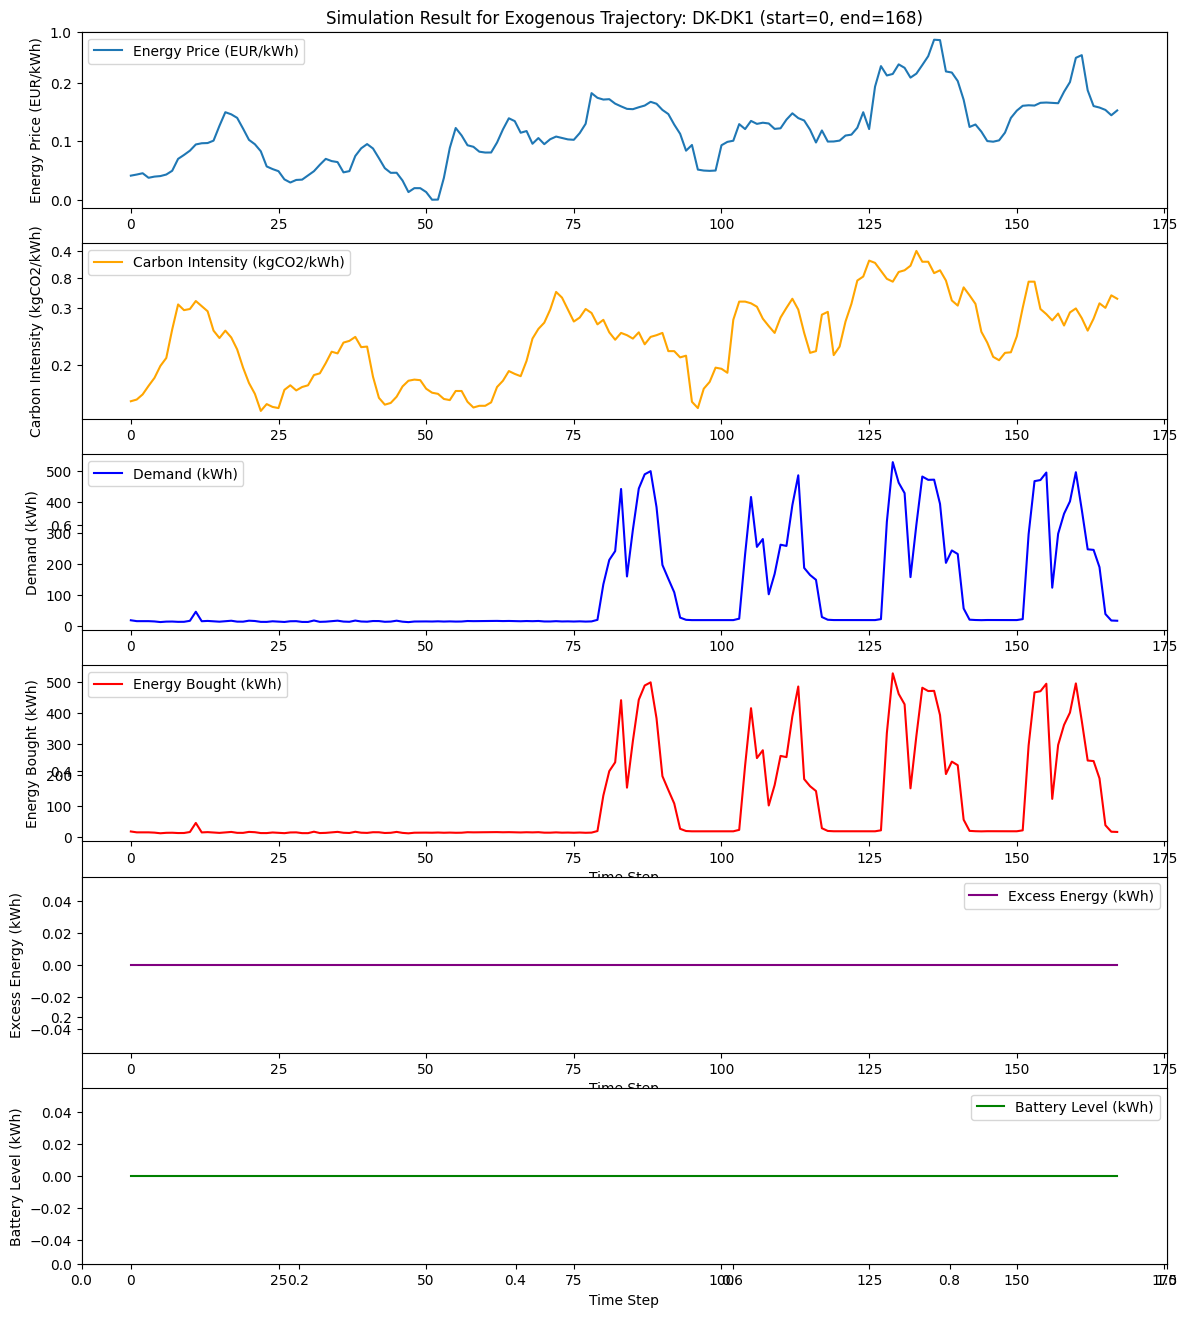

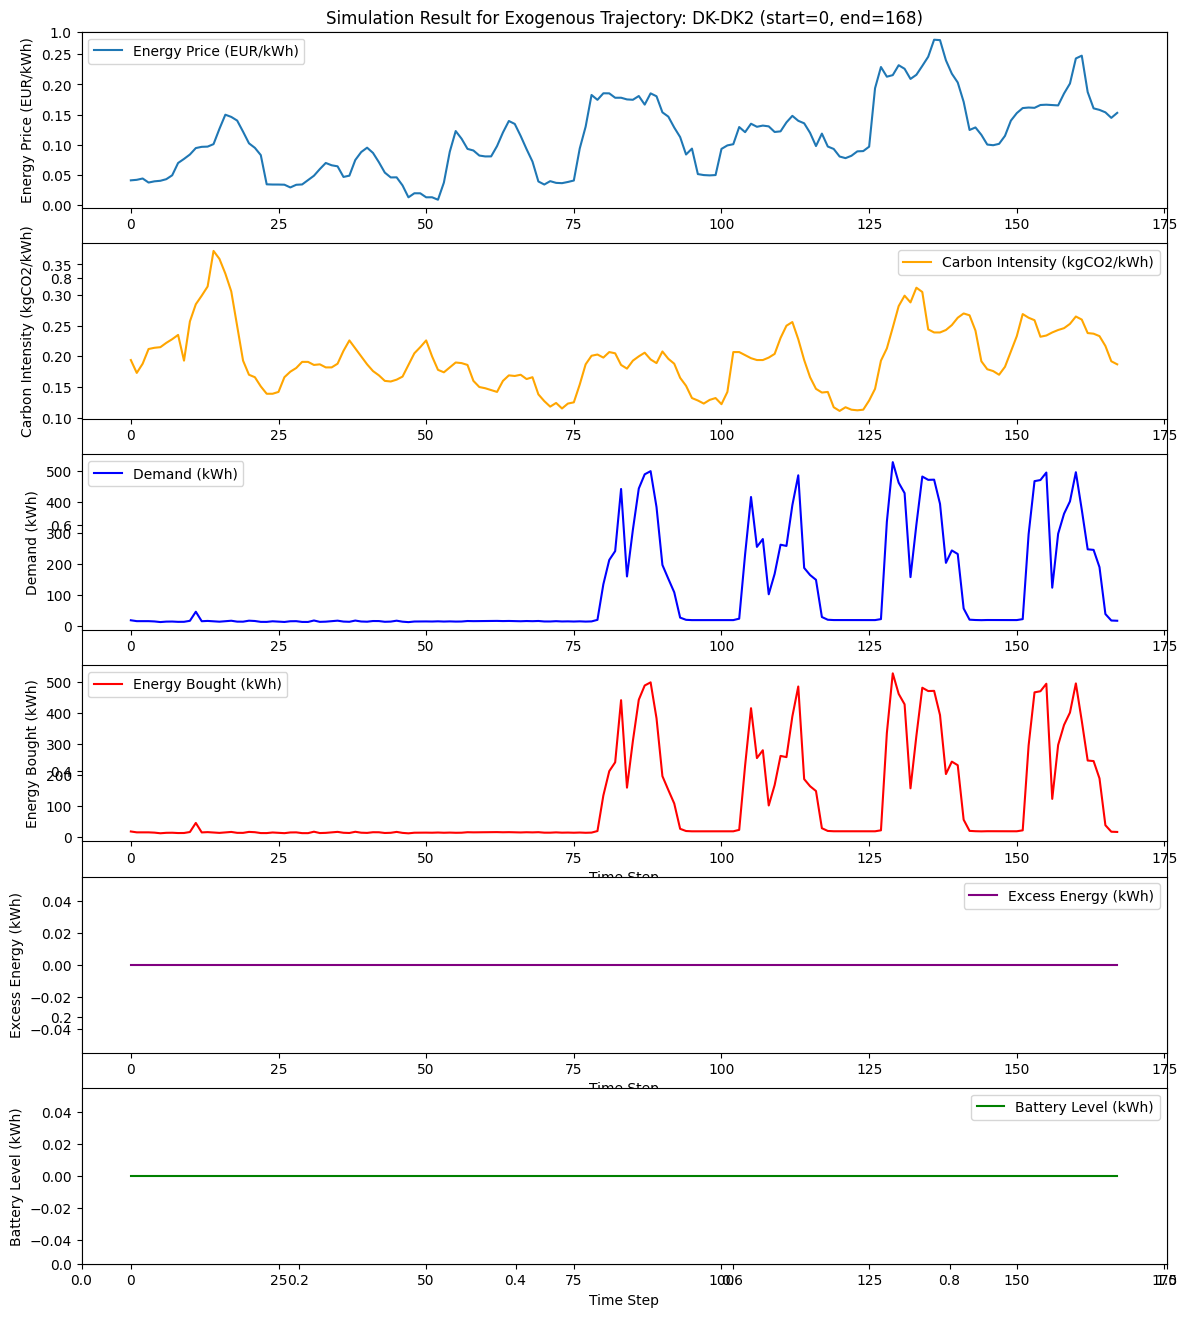

Policy: OptimizeOverNextDayAgent
Average amount: 267009.82
Average carbon_emissions: 311638.18
Average weighted_cost: 267009.82


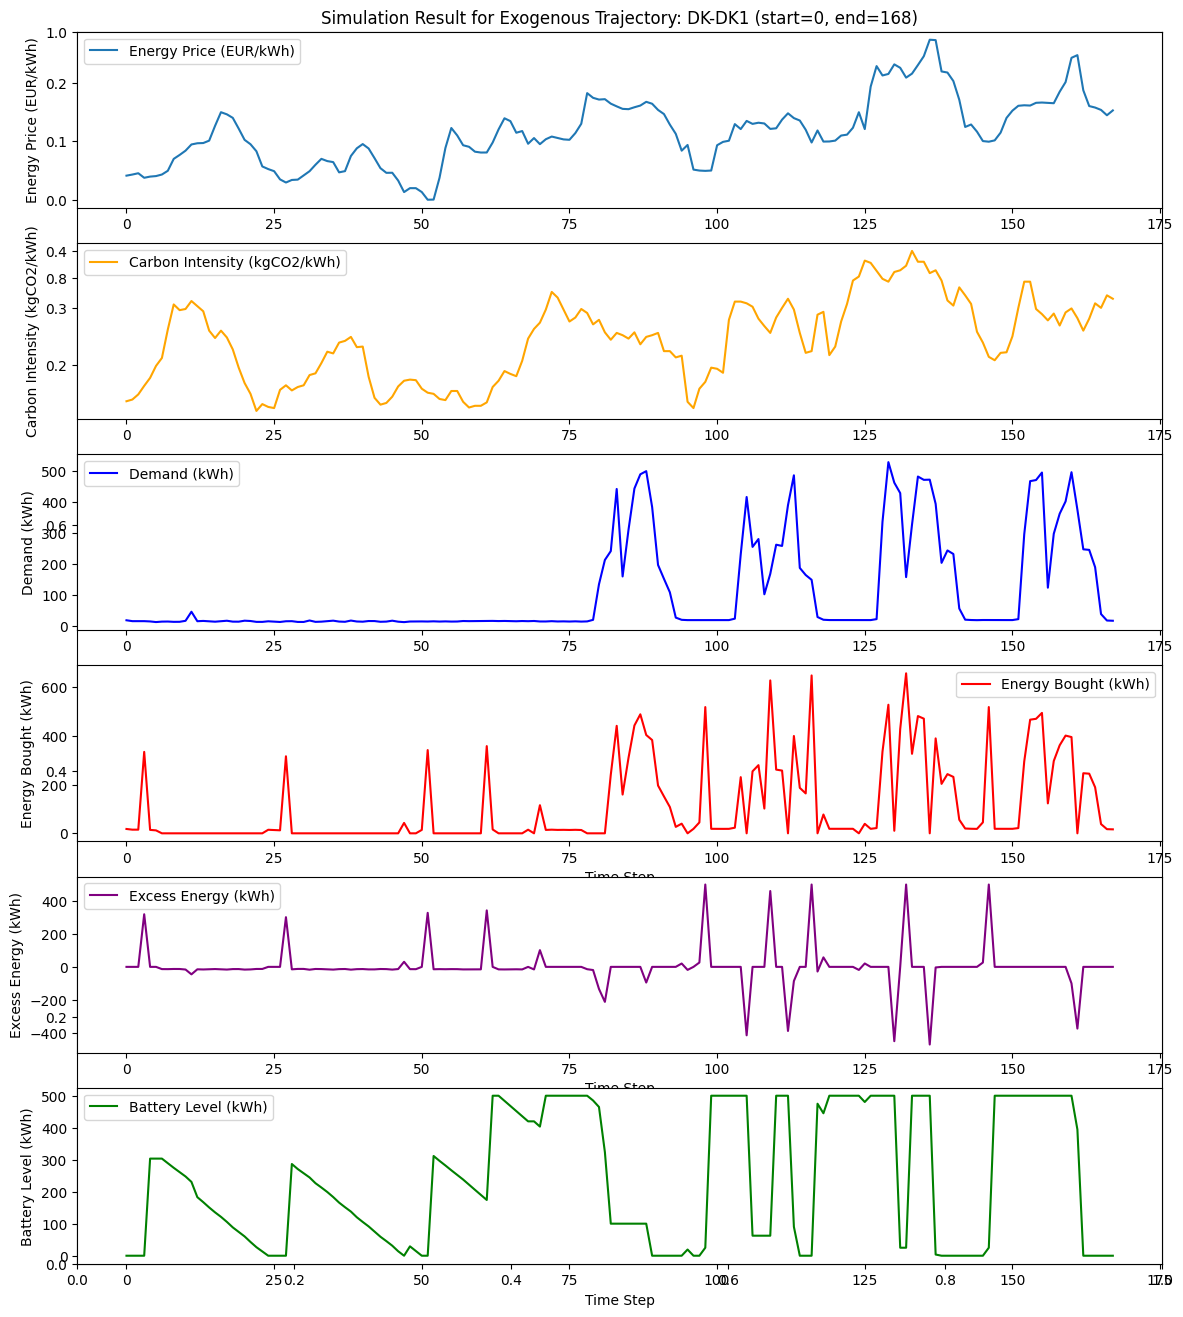

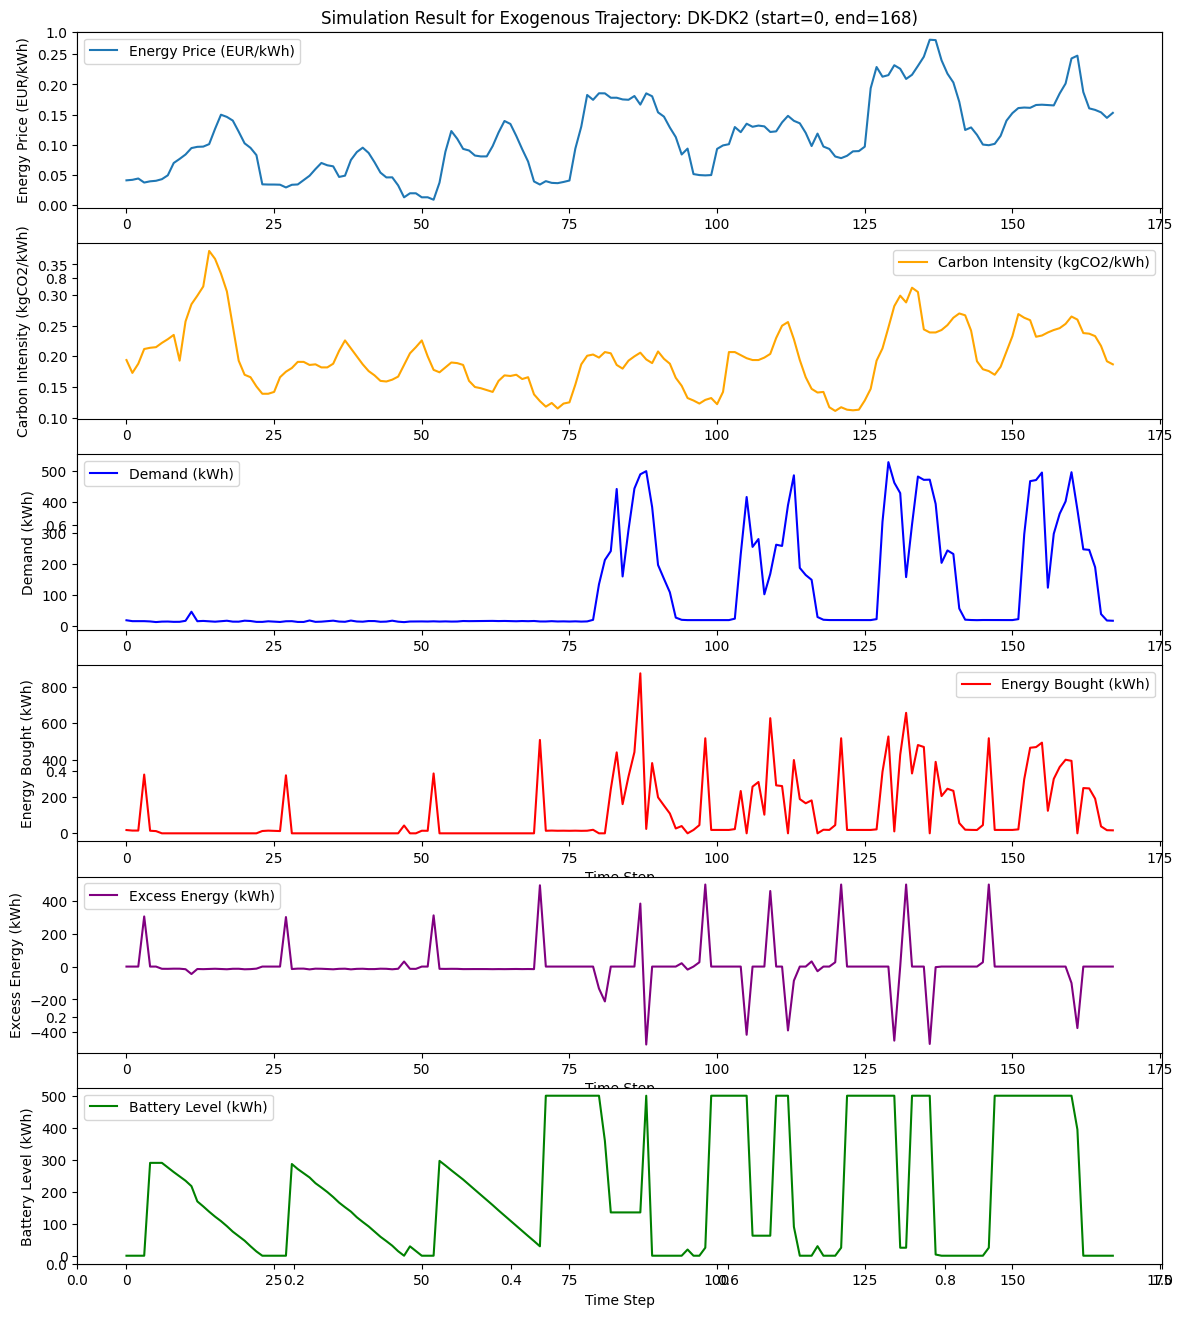

Policy: OptimizeOverNextDayWithBatteryValueAgent
Average amount: 266666.79
Average carbon_emissions: 311583.36
Average weighted_cost: 266666.79


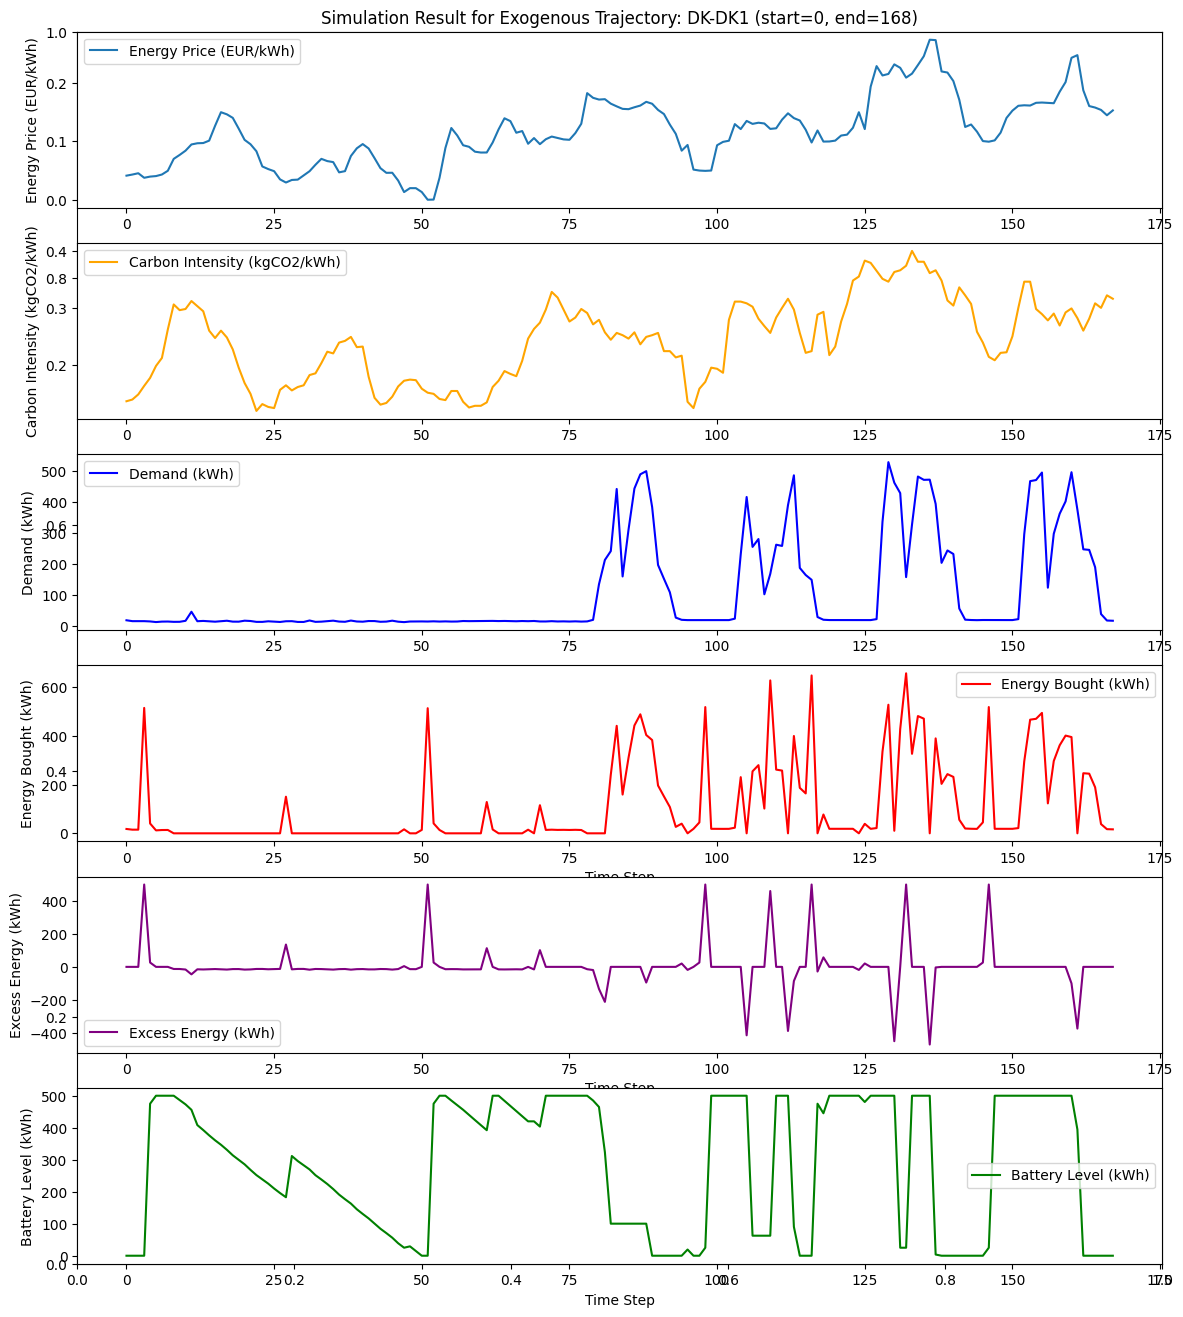

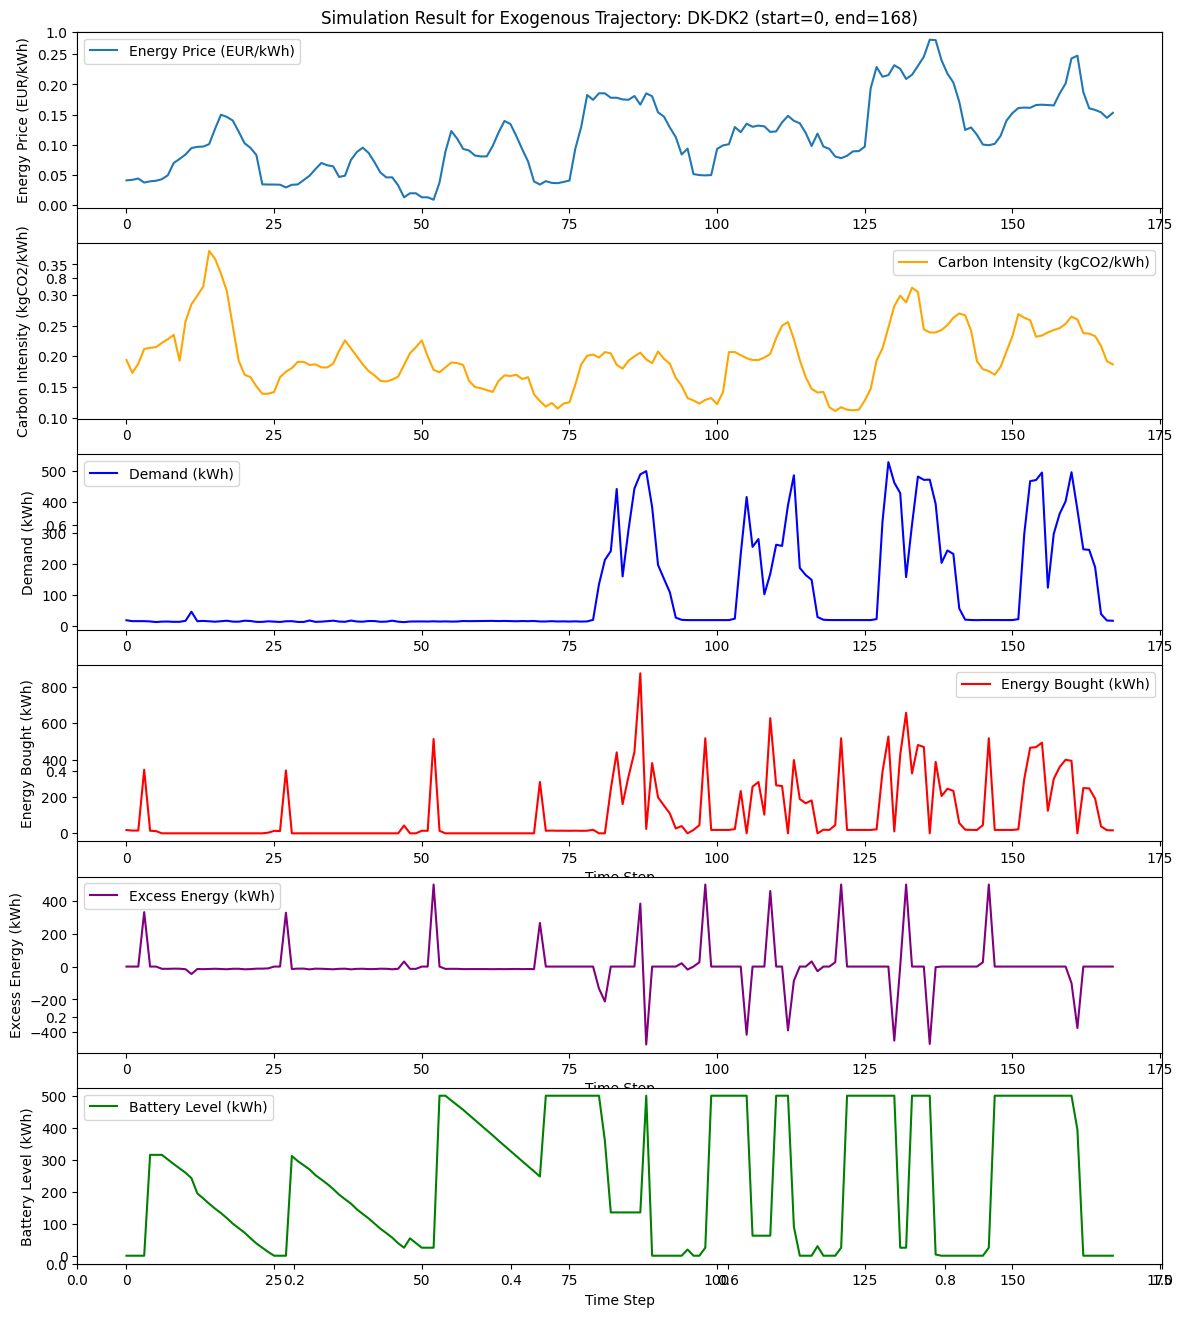

Policy: OptimalHindsightAgent
Average amount: 266510.88
Average carbon_emissions: 311518.65
Average weighted_cost: 266510.88


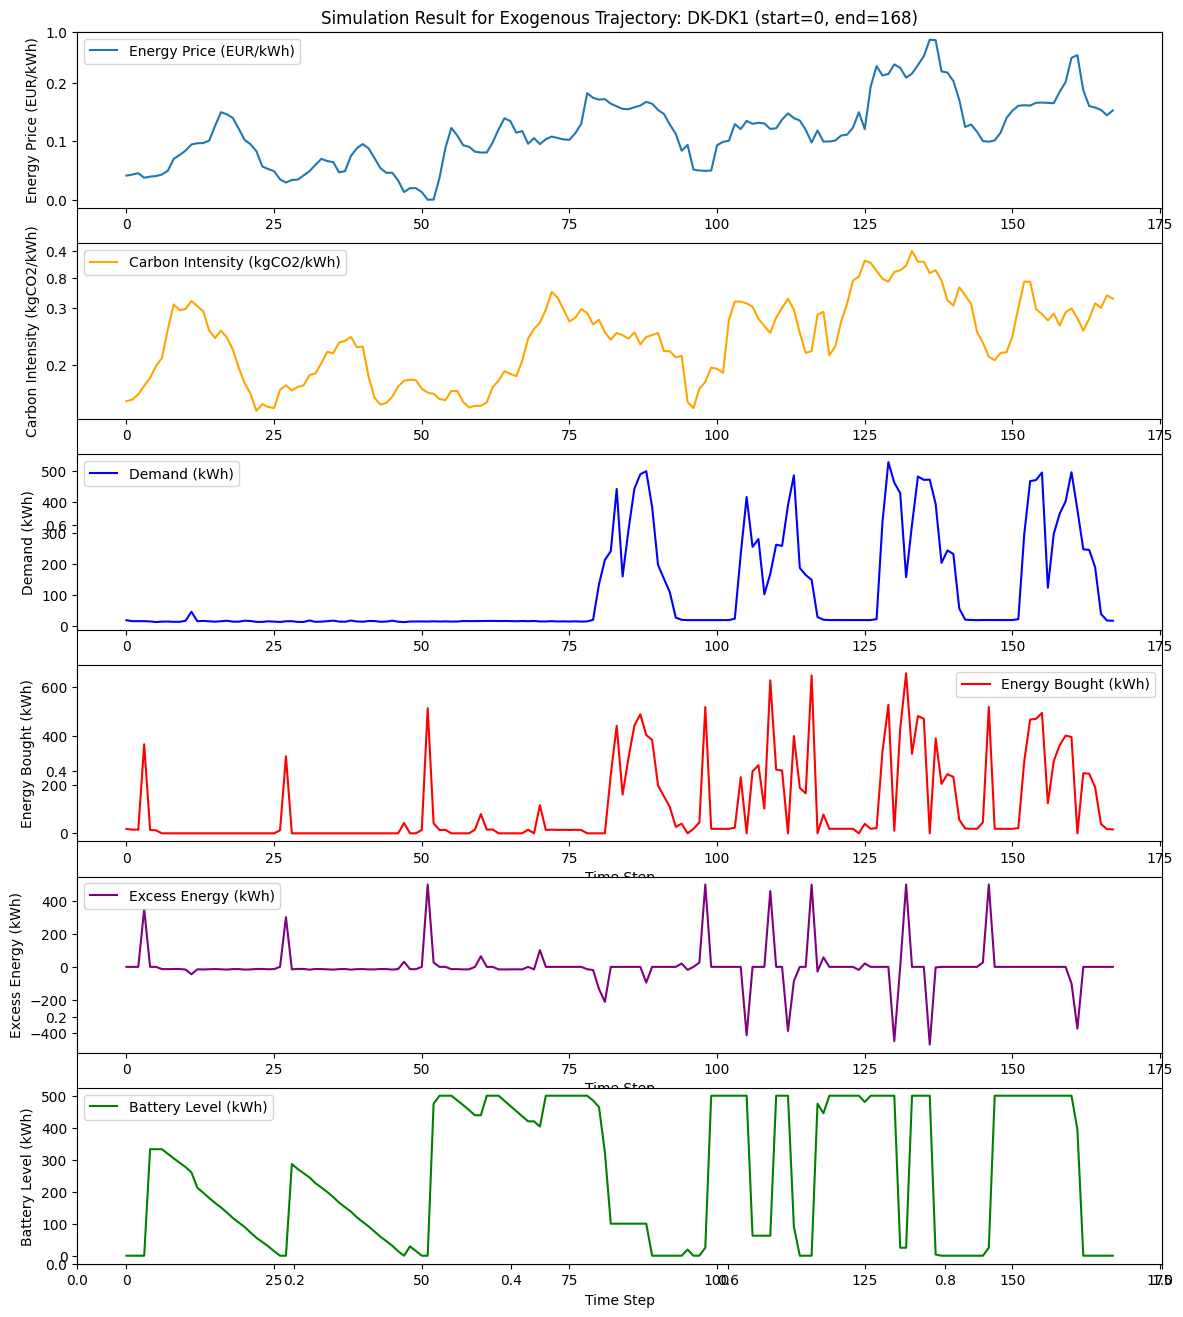

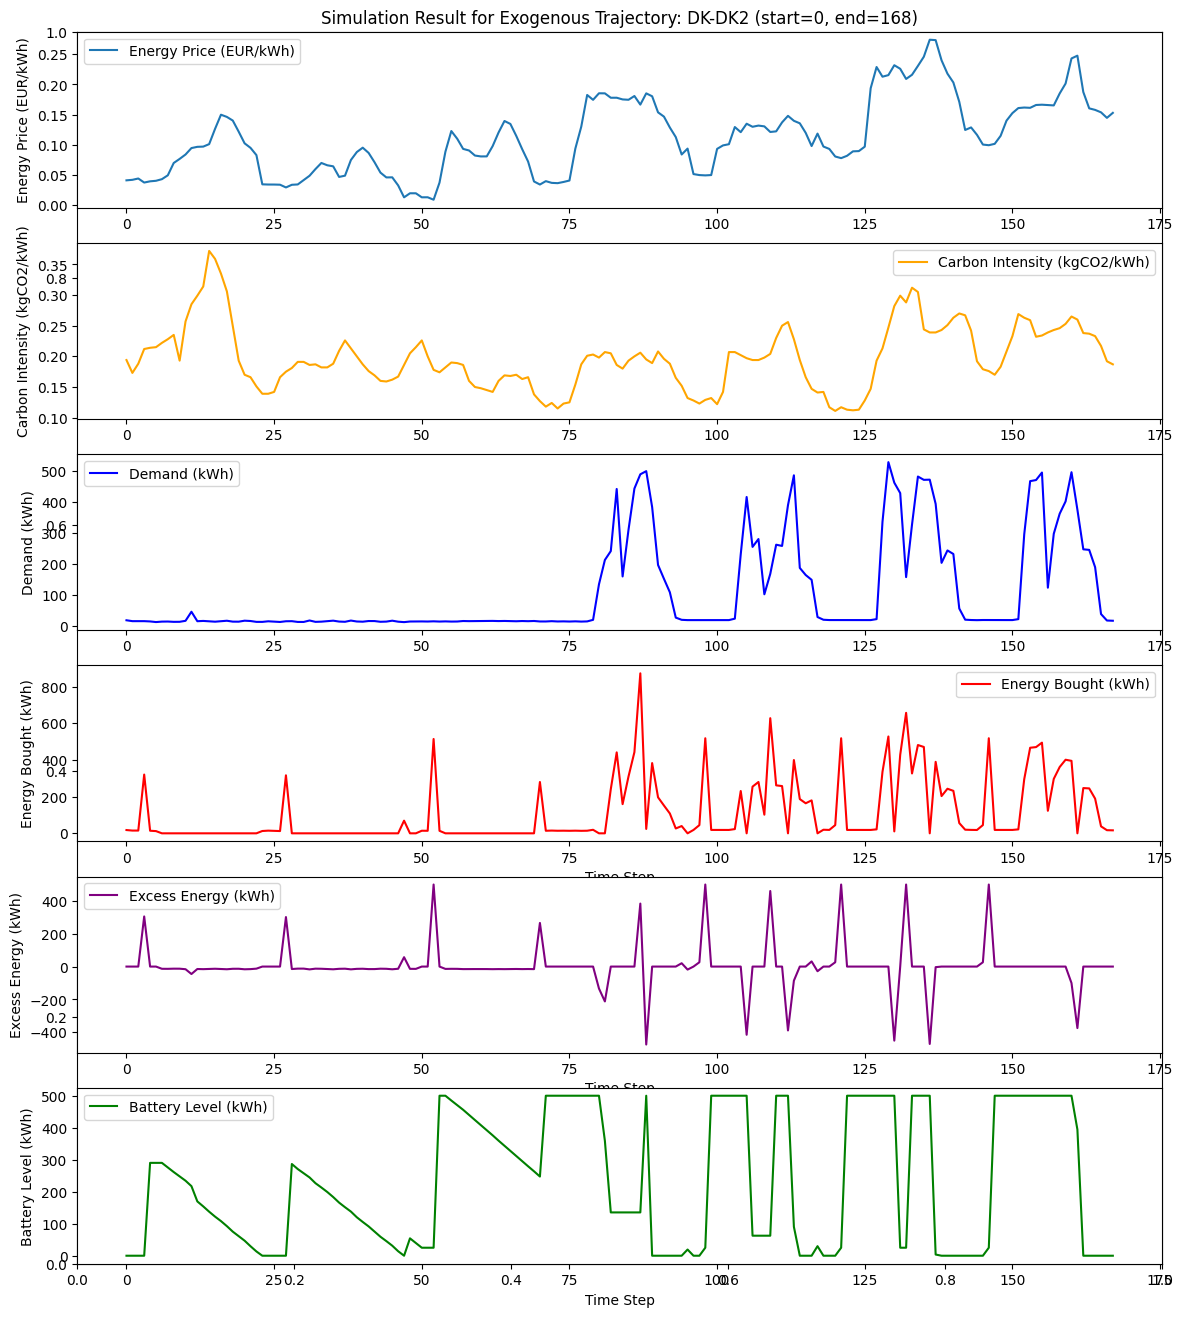

In [ ]:
start = 0

end = 24 * 7




for result in all_results:
    print(f"Policy: {result.policy_name}")
    result.print_average_costs()
    for sim in result.simulation_results:
        sim.plot(environment, start=start, end=end)
        


In [ ]:
# print table for each cost where rows are policies and columns are zones

for cost_type in ['amount', 'carbon_emissions', 'weighted_cost']:
    print(f"Average {cost_type} for each policy and zone:")
    df = pd.DataFrame(columns=['Policy'] + list(zones))
    for result in all_results:
        row = {'Policy': result.policy_name}
        for sim in result.simulation_results:
            row[sim.exogen_trajectory.zone] = sim.get_total_cost(cost_type)
        df.loc[len(df)] = row
    print(df.to_string(index=False))

Average amount for each policy and zone:
                                  Policy        DK-DK1        DK-DK2
                              DummyAgent 307511.479086 298646.221144
                OptimizeOverNextDayAgent 273101.299377 260918.348119
OptimizeOverNextDayWithBatteryValueAgent 272751.895085 260581.687418
                   OptimalHindsightAgent 272598.495285 260423.272182
Average carbon_emissions for each policy and zone:
                                  Policy        DK-DK1        DK-DK2
                              DummyAgent 324495.436200 303502.681190
                OptimizeOverNextDayAgent 322811.884194 300464.467623
OptimizeOverNextDayWithBatteryValueAgent 322919.104603 300247.625058
                   OptimalHindsightAgent 322812.825551 300224.470544
Average weighted_cost for each policy and zone:
                                  Policy        DK-DK1        DK-DK2
                              DummyAgent 307511.479086 298646.221144
                OptimizeOverNext

In [ ]:
# Economic savings compared to dummy agent
dummy_results = next(result for result in all_results if result.policy_name == 'DummyAgent').simulation_results
for result in all_results:
    if result.policy_name == 'DummyAgent':
        continue
    print(f"Economic savings for {result.policy_name} compared to DummyAgent:")
    df = pd.DataFrame(columns=['Zone', 'Dummy Cost', 'Cost','Total Savings', 'Savings per year'])
    for sim, dummy_sim in zip(result.simulation_results, dummy_results):
        dummy_cost = dummy_sim.get_total_cost('amount')
        policy_cost = sim.get_total_cost('amount')
        savings = dummy_cost - policy_cost
        savings_per_year = savings/ (len(sim.states) / (24 * 365))  # Annualize savings based on the number of time steps in the simulation
        df.loc[len(df)] = [sim.exogen_trajectory.zone, dummy_cost, policy_cost, savings, savings_per_year]
    print(df.to_string(index=False))

Economic savings for OptimizeOverNextDayAgent compared to DummyAgent:
  Zone    Dummy Cost          Cost  Total Savings  Savings per year
DK-DK1 307511.479086 273101.299377   34410.179709      17227.706135
DK-DK2 298646.221144 260918.348119   37727.873025      18888.733366
Economic savings for OptimizeOverNextDayWithBatteryValueAgent compared to DummyAgent:
  Zone    Dummy Cost          Cost  Total Savings  Savings per year
DK-DK1 307511.479086 272751.895085   34759.584001      17402.637929
DK-DK2 298646.221144 260581.687418   38064.533726      19057.284988
Economic savings for OptimalHindsightAgent compared to DummyAgent:
  Zone    Dummy Cost          Cost  Total Savings  Savings per year
DK-DK1 307511.479086 272598.495285   34912.983801      17479.438652
DK-DK2 298646.221144 260423.272182   38222.948962      19136.596726


In [ ]:
# saving per year for each policy



# Conclusion

With our model it is easy to compare the different policies and different battery parameters to see how they affect the cost savings for the consumer.

This makes it possible to determine the optimal battery size and charging/discharging strategy for a given consumer, based on their demand profile and the market conditions.


As an example, with the 500 kWh battery and our agent, we can on average save about 17,500 EUR per year compared to just buying energy from the market without using the battery.

Assuming that the battery has a lifetime of 10 years and a market rate of 5% per year, the present value of the savings from using the battery over its lifetime is:

$$PV = \sum_{t=1}^{10} \frac{17500}{(1 + 0.05)^t} = 135,130.36 \text{ EUR}$$

So if the battery costs less than 135,130.36 EUR, it would be a cost-effective investment for the consumer based on these assumptions.


Reduce carbon


Act as backup power source during outages
- maybe simulate this????


In [ ]:
battery_lifetime = 10 
savings_per_year = 17500
market_rate = 0.05

print(f"Netpresent value of savings over {battery_lifetime} years: {sum(savings_per_year / (1 + market_rate) ** year for year in range(1, battery_lifetime + 1)):.2f} EUR")

Netpresent value of savings over 10 years: 135130.36 EUR
